# Step 1: Data Collection & Event Window Construction

In [ ]:
import os, time, re, json, warnings
import requests
import numpy as np
import pandas as pd
import yfinance as yf
from bs4 import BeautifulSoup
from tqdm.notebook import tqdm

warnings.filterwarnings('ignore')

DATA_RAW  = 'data/raw'
DATA_PROC = 'data/processed'
os.makedirs(DATA_RAW,  exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)

SEC_HEADERS = {'User-Agent': 'Yuhao Dong yuhao@umich.edu'}

MARKET_START = '2015-01-01'
MARKET_END   = '2024-12-31'
FILING_START = '2015-01-01'
FILING_END   = '2024-06-30'

## 1. Stock Universe — S&P 100

In [ ]:
wiki_headers = {'User-Agent': 'Mozilla/5.0 (compatible; academic research bot)'}
wiki_resp = requests.get(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies',
    headers=wiki_headers, timeout=15
)
wiki_resp.raise_for_status()
sp500_table = pd.read_html(wiki_resp.text)[0]
SP500_TICKERS_RAW = sp500_table['Symbol'].str.replace('.', '-', regex=False).tolist()
print(f'S&P 500 tickers from Wikipedia: {len(SP500_TICKERS_RAW)}')

filter_cache = os.path.join(DATA_RAW, 'sp500_filtered_tickers.json')
if os.path.exists(filter_cache):
    with open(filter_cache) as f:
        SP500_TICKERS = json.load(f)
    print(f'Loaded cached filtered universe: {len(SP500_TICKERS)} tickers')
else:
    print('Filtering for tickers with full history since 2015 (takes ~3 min)...')
    SP500_TICKERS = []
    for ticker in tqdm(SP500_TICKERS_RAW, desc='Checking history'):
        try:
            hist = yf.Ticker(ticker).history(start='2015-01-01', end='2015-07-01', timeout=5)
            if len(hist) >= 60:
                SP500_TICKERS.append(ticker)
        except Exception:
            pass
        time.sleep(0.05)
    with open(filter_cache, 'w') as f:
        json.dump(SP500_TICKERS, f)
    print(f'Survivorship-filtered universe: {len(SP500_TICKERS)} tickers')

print(f'\nFinal universe: {len(SP500_TICKERS)} tickers (excludes post-2015 additions)')

S&P 500 tickers from Wikipedia: 503
Loaded cached filtered universe: 463 tickers

Final universe: 463 tickers (excludes post-2015 additions)


## 2. Daily Market Data via yfinance

In [ ]:
raw_price_path = os.path.join(DATA_RAW, 'prices_daily.parquet')

if os.path.exists(raw_price_path):
    prices = pd.read_parquet(raw_price_path)
    print('Loaded cached prices.')
else:
    print(f'Downloading daily OHLCV for {len(SP500_TICKERS)} tickers (2015-2024)...')
    raw = yf.download(
        SP500_TICKERS,
        start=MARKET_START,
        end=MARKET_END,
        auto_adjust=True,
        progress=True,
    )
    close  = raw['Close'].copy()
    volume = raw['Volume'].copy()
    close.index  = pd.to_datetime(close.index)
    volume.index = pd.to_datetime(volume.index)

    prices = pd.concat([close.stack(), volume.stack()], axis=1)
    prices.index.names = ['date', 'ticker']
    prices.columns = ['close', 'volume']
    prices = prices.reset_index().sort_values(['ticker', 'date']).reset_index(drop=True)
    prices.to_parquet(raw_price_path, index=False)
    print(f'Saved: {raw_price_path}  shape={prices.shape}')

prices['date'] = pd.to_datetime(prices['date'])
print(prices.head())
print(f'Date range: {prices.date.min()} — {prices.date.max()}')
print(f'Tickers: {prices.ticker.nunique()}')

Loaded cached prices.
        date ticker      close     volume
0 2015-01-02      A  36.970371  1529200.0
1 2015-01-05      A  36.277637  2041800.0
2 2015-01-06      A  35.712482  2080600.0
3 2015-01-07      A  36.186466  3359700.0
4 2015-01-08      A  37.271149  2116300.0
Date range: 2015-01-02 00:00:00 — 2024-12-30 00:00:00
Tickers: 463


## 3. Market Feature Engineering

In [12]:
feat_path = os.path.join(DATA_PROC, 'market_features.parquet')

if os.path.exists(feat_path):
    mkt = pd.read_parquet(feat_path)
    print('Loaded cached market features.')
else:
    df = prices.copy()
    df = df.sort_values(['ticker', 'date'])

    df['logret'] = df.groupby('ticker')['close'].transform(lambda x: np.log(x).diff())

    for w in [1, 5, 20, 60]:
        df[f'ret_{w}d_lag'] = df.groupby('ticker')['logret'].transform(
            lambda x: x.shift(1).rolling(w).sum()
        )

    df['mom_12m_1m'] = df.groupby('ticker')['logret'].transform(
        lambda x: x.shift(21).rolling(231).sum()
    )

    for w, col in [(20, 'rvol_20d'), (60, 'rvol_60d')]:
        df[col] = df.groupby('ticker')['logret'].transform(
            lambda x: x.shift(1).rolling(w).std() * np.sqrt(252)
        )
    
    df['vol_zscore_20d'] = df.groupby('ticker')['volume'].transform(
        lambda x: (x - x.shift(1).rolling(20).mean()) / (x.shift(1).rolling(20).std() + 1e-8)
    )

    for w in [5, 20]:
        df[f'fwd_ret_{w}d'] = df.groupby('ticker')['logret'].transform(
            lambda x: x.shift(-w).rolling(w).sum()
        )

    mkt_cols = ['date', 'ticker', 'close',
                'ret_1d_lag', 'ret_5d_lag', 'ret_20d_lag', 'ret_60d_lag',
                'mom_12m_1m', 'rvol_20d', 'rvol_60d', 'vol_zscore_20d',
                'fwd_ret_5d', 'fwd_ret_20d']
    mkt = df[mkt_cols].dropna(subset=['rvol_20d']).reset_index(drop=True)
    mkt.to_parquet(feat_path, index=False)
    print(f'Saved: {feat_path}  shape={mkt.shape}')

mkt['date'] = pd.to_datetime(mkt['date'])
print(mkt.describe())

Loaded cached market features.
                                date         close    ret_1d_lag  \
count                        1154662  1.154662e+06  1.154662e+06   
mean   2020-01-15 09:19:53.772722944  1.168368e+02  4.568293e-04   
min              2015-02-03 00:00:00  4.672476e-01 -7.735928e-01   
25%              2017-07-25 00:00:00  3.868443e+01 -8.142415e-03   
50%              2020-01-16 00:00:00  7.073000e+01  7.899728e-04   
75%              2022-07-08 00:00:00  1.309482e+02  9.558806e-03   
max              2024-12-30 00:00:00  9.924400e+03  5.572887e-01   
std                              NaN  2.417806e+02  2.020559e-02   

         ret_5d_lag   ret_20d_lag   ret_60d_lag    mom_12m_1m      rvol_20d  \
count  1.154662e+06  1.154662e+06  1.136142e+06  1.047709e+06  1.154662e+06   
mean   2.259424e-03  9.257309e-03  2.756007e-02  1.059281e-01  2.740733e-01   
min   -1.143139e+00 -2.055640e+00 -2.089779e+00 -2.104897e+00  0.000000e+00   
25%   -1.769487e-02 -3.318558e-02 -4.571

## 4. SEC Ticker → CIK Mapping

In [5]:
cik_path = os.path.join(DATA_RAW, 'ticker_cik.json')

if os.path.exists(cik_path):
    with open(cik_path) as f:
        ticker_cik_raw = json.load(f)
else:
    resp = requests.get('https://www.sec.gov/files/company_tickers.json', headers=SEC_HEADERS)
    resp.raise_for_status()
    ticker_cik_raw = resp.json()
    with open(cik_path, 'w') as f:
        json.dump(ticker_cik_raw, f)

cik_map = {
    entry['ticker']: str(entry['cik_str']).zfill(10)
    for entry in ticker_cik_raw.values()
}

missing = [t for t in SP500_TICKERS if t not in cik_map]
print(f'CIK mapping: {len(SP500_TICKERS) - len(missing)}/{len(SP500_TICKERS)} tickers found')
if missing:
    print('Missing:', missing[:10], '...' if len(missing) > 10 else '')

UNIVERSE = [t for t in SP500_TICKERS if t in cik_map]
print(f'Final universe for SEC filing download: {len(UNIVERSE)} tickers')

CIK mapping: 463/463 tickers found
Final universe for SEC filing download: 463 tickers


## 5. SEC Filing Metadata via Submissions API

In [ ]:
FILING_FORMS = {'10-Q', '10-K'}

def get_filing_metadata(cik: str, ticker: str) -> pd.DataFrame:
    """Fetch filing history for one CIK, return DataFrame of target form types."""
    url = f'https://data.sec.gov/submissions/CIK{cik}.json'
    resp = requests.get(url, headers=SEC_HEADERS, timeout=15)
    resp.raise_for_status()
    data = resp.json()

    recent = data.get('filings', {}).get('recent', {})
    if not recent or 'form' not in recent:
        return pd.DataFrame()

    df = pd.DataFrame({
        'form':        recent['form'],
        'filing_date': pd.to_datetime(recent['filingDate']),
        'accession':   recent['accessionNumber'],
        'primaryDoc':  recent['primaryDocument'],
    })

    for extra in data.get('filings', {}).get('files', []):
        extra_url = f"https://data.sec.gov/submissions/{extra['name']}"
        try:
            er = requests.get(extra_url, headers=SEC_HEADERS, timeout=15)
            er.raise_for_status()
            ed = er.json()
            edf = pd.DataFrame({
                'form':        ed['form'],
                'filing_date': pd.to_datetime(ed['filingDate']),
                'accession':   ed['accessionNumber'],
                'primaryDoc':  ed['primaryDocument'],
            })
            df = pd.concat([df, edf], ignore_index=True)
        except Exception:
            pass

    df = df[df['form'].isin(FILING_FORMS)].copy()
    df = df.drop_duplicates(subset='accession').reset_index(drop=True)
    df['ticker'] = ticker
    df['cik']    = cik
    return df


meta_path = os.path.join(DATA_RAW, 'filing_metadata.parquet')

if os.path.exists(meta_path):
    meta = pd.read_parquet(meta_path)
    n_before = len(meta)
    meta = meta.drop_duplicates(subset='accession').reset_index(drop=True)
    if len(meta) != n_before:
        print(f'[dedup] filing_metadata: {n_before} -> {len(meta)} rows')
        meta.to_parquet(meta_path, index=False)
    print('Loaded cached filing metadata.')
else:
    records = []
    for ticker in tqdm(UNIVERSE, desc='Fetching SEC metadata'):
        cik = cik_map[ticker]
        try:
            df = get_filing_metadata(cik, ticker)
            records.append(df)
        except Exception as e:
            print(f'  [{ticker}] error: {e}')
        time.sleep(0.12)

    meta = pd.concat(records, ignore_index=True)
    meta = meta[
        (meta['filing_date'] >= FILING_START) &
        (meta['filing_date'] <= FILING_END)
    ].reset_index(drop=True)
    meta = meta.drop_duplicates(subset='accession').reset_index(drop=True)
    meta.to_parquet(meta_path, index=False)
    print(f'Saved: {meta_path}  shape={meta.shape}')

assert meta['accession'].is_unique, \
    f'meta has duplicate accessions: {len(meta)} rows vs {meta["accession"].nunique()} unique'

print(meta['form'].value_counts())
print(f'Date range: {meta.filing_date.min()} — {meta.filing_date.max()}')
print(meta.head())

## 6. Download and Clean Filing Text

In [ ]:
FILINGS_DIR = os.path.join(DATA_RAW, 'filings')
os.makedirs(FILINGS_DIR, exist_ok=True)

def accession_to_path(accession: str) -> str:
    return accession.replace('-', '')


def fetch_filing_text(cik: str, accession: str, primary_doc: str) -> str:
    acc_clean = accession_to_path(accession)
    base_url  = f'https://www.sec.gov/Archives/edgar/data/{int(cik)}/{acc_clean}'

    for doc in [primary_doc, f'{acc_clean}.txt']:
        if not doc:
            continue
        url = f'{base_url}/{doc}'
        try:
            r = requests.get(url, headers=SEC_HEADERS, timeout=30)
            if r.status_code == 200 and len(r.text) > 500:
                return r.text
        except Exception:
            pass
    return ''


def clean_html_text(raw_html: str, max_chars: int = 60_000) -> str:
    soup = BeautifulSoup(raw_html, 'lxml')
    # Remove XBRL, scripts, style blocks
    for tag in soup(['script', 'style', 'ix:nonfraction', 'ix:nonnumeric',
                     'ix:header', 'xbrl']):
        tag.decompose()
    text = soup.get_text(separator=' ')
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove lines that are just numbers/dates (table rows)
    lines = [l.strip() for l in text.split('\n') if len(l.strip()) > 20]
    text = ' '.join(lines)
    return text[:max_chars]


def get_or_download_filing(row) -> str:
    fname = os.path.join(FILINGS_DIR, f"{row['accession']}.txt")
    if os.path.exists(fname):
        with open(fname, encoding='utf-8') as f:
            return f.read()
    raw = fetch_filing_text(row['cik'], row['accession'], row['primaryDoc'])
    if not raw:
        return ''
    text = clean_html_text(raw)
    with open(fname, 'w', encoding='utf-8') as f:
        f.write(text)
    return text


print(f'Downloading text for {len(meta)} filings...')
print('(This will take several minutes; each filing is cached after first download)')

(This will take several minutes; each filing is cached after first download)


In [ ]:
texts = []
for _, row in tqdm(meta.iterrows(), total=len(meta), desc='Downloading filings'):
    text = get_or_download_filing(row)
    texts.append(text)
    if not os.path.exists(os.path.join(FILINGS_DIR, f"{row['accession']}.txt")):
        time.sleep(0.15)

meta['text'] = texts
empty_count = (meta['text'].str.len() < 100).sum()
print(f'Empty/short texts: {empty_count}/{len(meta)}')
meta = meta[meta['text'].str.len() >= 100].reset_index(drop=True)
print(f'Usable filings: {len(meta)}')

Empty/short texts: 0/17116
Usable filings: 17116


## 7. Event Window Construction & Label Alignment

In [ ]:
mkt_avg = (
    mkt.groupby('date')[['fwd_ret_5d', 'fwd_ret_20d']]
    .mean()
    .rename(columns={'fwd_ret_5d': 'mkt_fwd_5d', 'fwd_ret_20d': 'mkt_fwd_20d'})
    .reset_index()
)

trading_dates = sorted(mkt['date'].unique())
trading_dates_set = set(trading_dates)


def next_trading_day(d: pd.Timestamp) -> pd.Timestamp:
    d = pd.Timestamp(d)
    for delta in range(10):
        candidate = d + pd.Timedelta(days=delta)
        if candidate in trading_dates_set:
            return candidate
    return None


event_rows = []
mkt_indexed = mkt.set_index(['ticker', 'date'])
mkt_avg_indexed = mkt_avg.set_index('date')

for _, row in tqdm(meta.iterrows(), total=len(meta), desc='Building event windows'):
    ticker = row['ticker']
    event_date = next_trading_day(row['filing_date'])
    if event_date is None:
        continue

    try:
        feat = mkt_indexed.loc[(ticker, event_date)]
    except KeyError:
        continue

    if pd.isna(feat['fwd_ret_5d']) or pd.isna(feat['fwd_ret_20d']):
        continue

    try:
        mkt_row = mkt_avg_indexed.loc[event_date]
        exc_5d  = feat['fwd_ret_5d']  - mkt_row['mkt_fwd_5d']
        exc_20d = feat['fwd_ret_20d'] - mkt_row['mkt_fwd_20d']
    except KeyError:
        exc_5d = feat['fwd_ret_5d']
        exc_20d = feat['fwd_ret_20d']

    event_rows.append({
        'ticker':       ticker,
        'cik':          row['cik'],
        'form':         row['form'],
        'filing_date':  row['filing_date'],
        'event_date':   event_date,
        'accession':    row['accession'],
        'ret_1d_lag':       feat['ret_1d_lag'],
        'ret_5d_lag':       feat['ret_5d_lag'],
        'ret_20d_lag':      feat['ret_20d_lag'],
        'ret_60d_lag':      feat['ret_60d_lag'],
        'mom_12m_1m':       feat['mom_12m_1m'],
        'rvol_20d':         feat['rvol_20d'],
        'rvol_60d':         feat['rvol_60d'],
        'vol_zscore_20d':   feat['vol_zscore_20d'],
        'fwd_ret_5d':   feat['fwd_ret_5d'],
        'fwd_ret_20d':  feat['fwd_ret_20d'],
        'exc_ret_5d':   exc_5d,
        'exc_ret_20d':  exc_20d,
        'text':         row['text'],
    })

events = pd.DataFrame(event_rows).sort_values(['ticker', 'event_date']).reset_index(drop=True)
print(f'Event dataset: {len(events)} rows')
print(events[['ticker', 'form', 'event_date', 'exc_ret_5d', 'exc_ret_20d']].head(10))

Building event windows:   0%|          | 0/17116 [00:00<?, ?it/s]

Event dataset: 17105 rows
  ticker  form event_date  exc_ret_5d  exc_ret_20d
0      A  10-Q 2015-03-10    0.002452     0.012093
1      A  10-Q 2015-06-05   -0.013550    -0.010417
2      A  10-Q 2015-09-02    0.003167    -0.035649
3      A  10-K 2015-12-21    0.006197    -0.004766
4      A  10-Q 2016-03-08   -0.012360     0.010674
5      A  10-Q 2016-06-07    0.003797    -0.013667
6      A  10-Q 2016-09-07   -0.015654     0.015675
7      A  10-K 2016-12-20   -0.000484     0.025703
8      A  10-Q 2017-03-08    0.038741     0.028585
9      A  10-Q 2017-06-06   -0.022723    -0.008390


## 8. Dataset Summary & Save

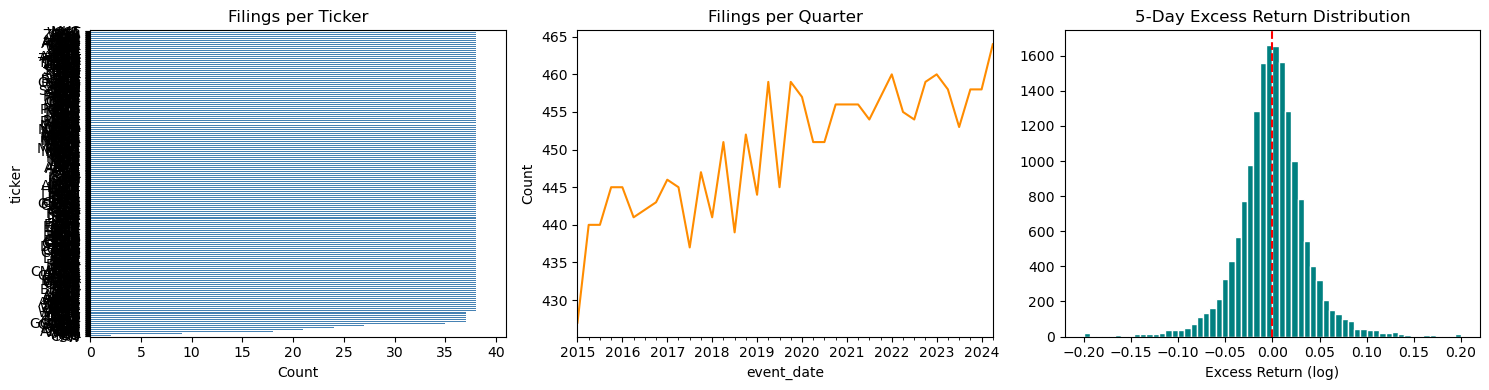


Label summary:
         exc_ret_5d   exc_ret_20d
count  17105.000000  17105.000000
mean      -0.000118     -0.000453
std        0.038283      0.070956
min       -0.645994     -1.394308
25%       -0.018883     -0.035835
50%       -0.000068      0.000081
75%        0.018564      0.034632
max        0.280674      0.576764


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

events.groupby('ticker').size().sort_values().plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Filings per Ticker')
axes[0].set_xlabel('Count')

events.set_index('event_date').resample('Q').size().plot(ax=axes[1], color='darkorange')
axes[1].set_title('Filings per Quarter')
axes[1].set_ylabel('Count')
axes[2].hist(events['exc_ret_5d'].clip(-0.2, 0.2), bins=60, color='teal', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_title('5-Day Excess Return Distribution')
axes[2].set_xlabel('Excess Return (log)')

plt.tight_layout()
plt.savefig('outputs/01_event_summary.png', dpi=150)
plt.show()

print('\nLabel summary:')
print(events[['exc_ret_5d', 'exc_ret_20d']].describe())

In [ ]:
n_before = len(events)
events = events.drop_duplicates(subset='accession').reset_index(drop=True)
if len(events) != n_before:
    print(f'[dedup] events: {n_before} -> {len(events)} rows')

assert events['accession'].is_unique, \
    f'events has duplicate accessions: {len(events)} vs {events["accession"].nunique()} unique'

events_no_text = events.drop(columns=['text'])
events_no_text.to_parquet(os.path.join(DATA_PROC, 'events.parquet'), index=False)

text_records = events[['accession', 'ticker', 'form', 'event_date', 'text']]
text_records.to_parquet(os.path.join(DATA_PROC, 'events_text.parquet'), index=False)

print('Saved:')
print(f'  data/processed/events.parquet      — {len(events_no_text)} rows, {len(events_no_text.columns)} cols')
print(f'  data/processed/events_text.parquet — {len(text_records)} rows (with text)')
print('\nStep 1 complete. Proceed to 02_finbert_baseline.ipynb')